<a href="https://colab.research.google.com/github/bobirjon06/Python/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
URL = "https://raw.githubusercontent.com/kb22/" \
      "Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(URL)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum().sum()

np.int64(0)

In [23]:
X = df.drop(columns='target')
y = df['target']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(max_depth = 3, random_state = 42)
model.fit(X_tr, y_tr)
print(model.score(X_tr, y_tr), model.score(X_te, y_te))

0.8464730290456431 0.7540983606557377


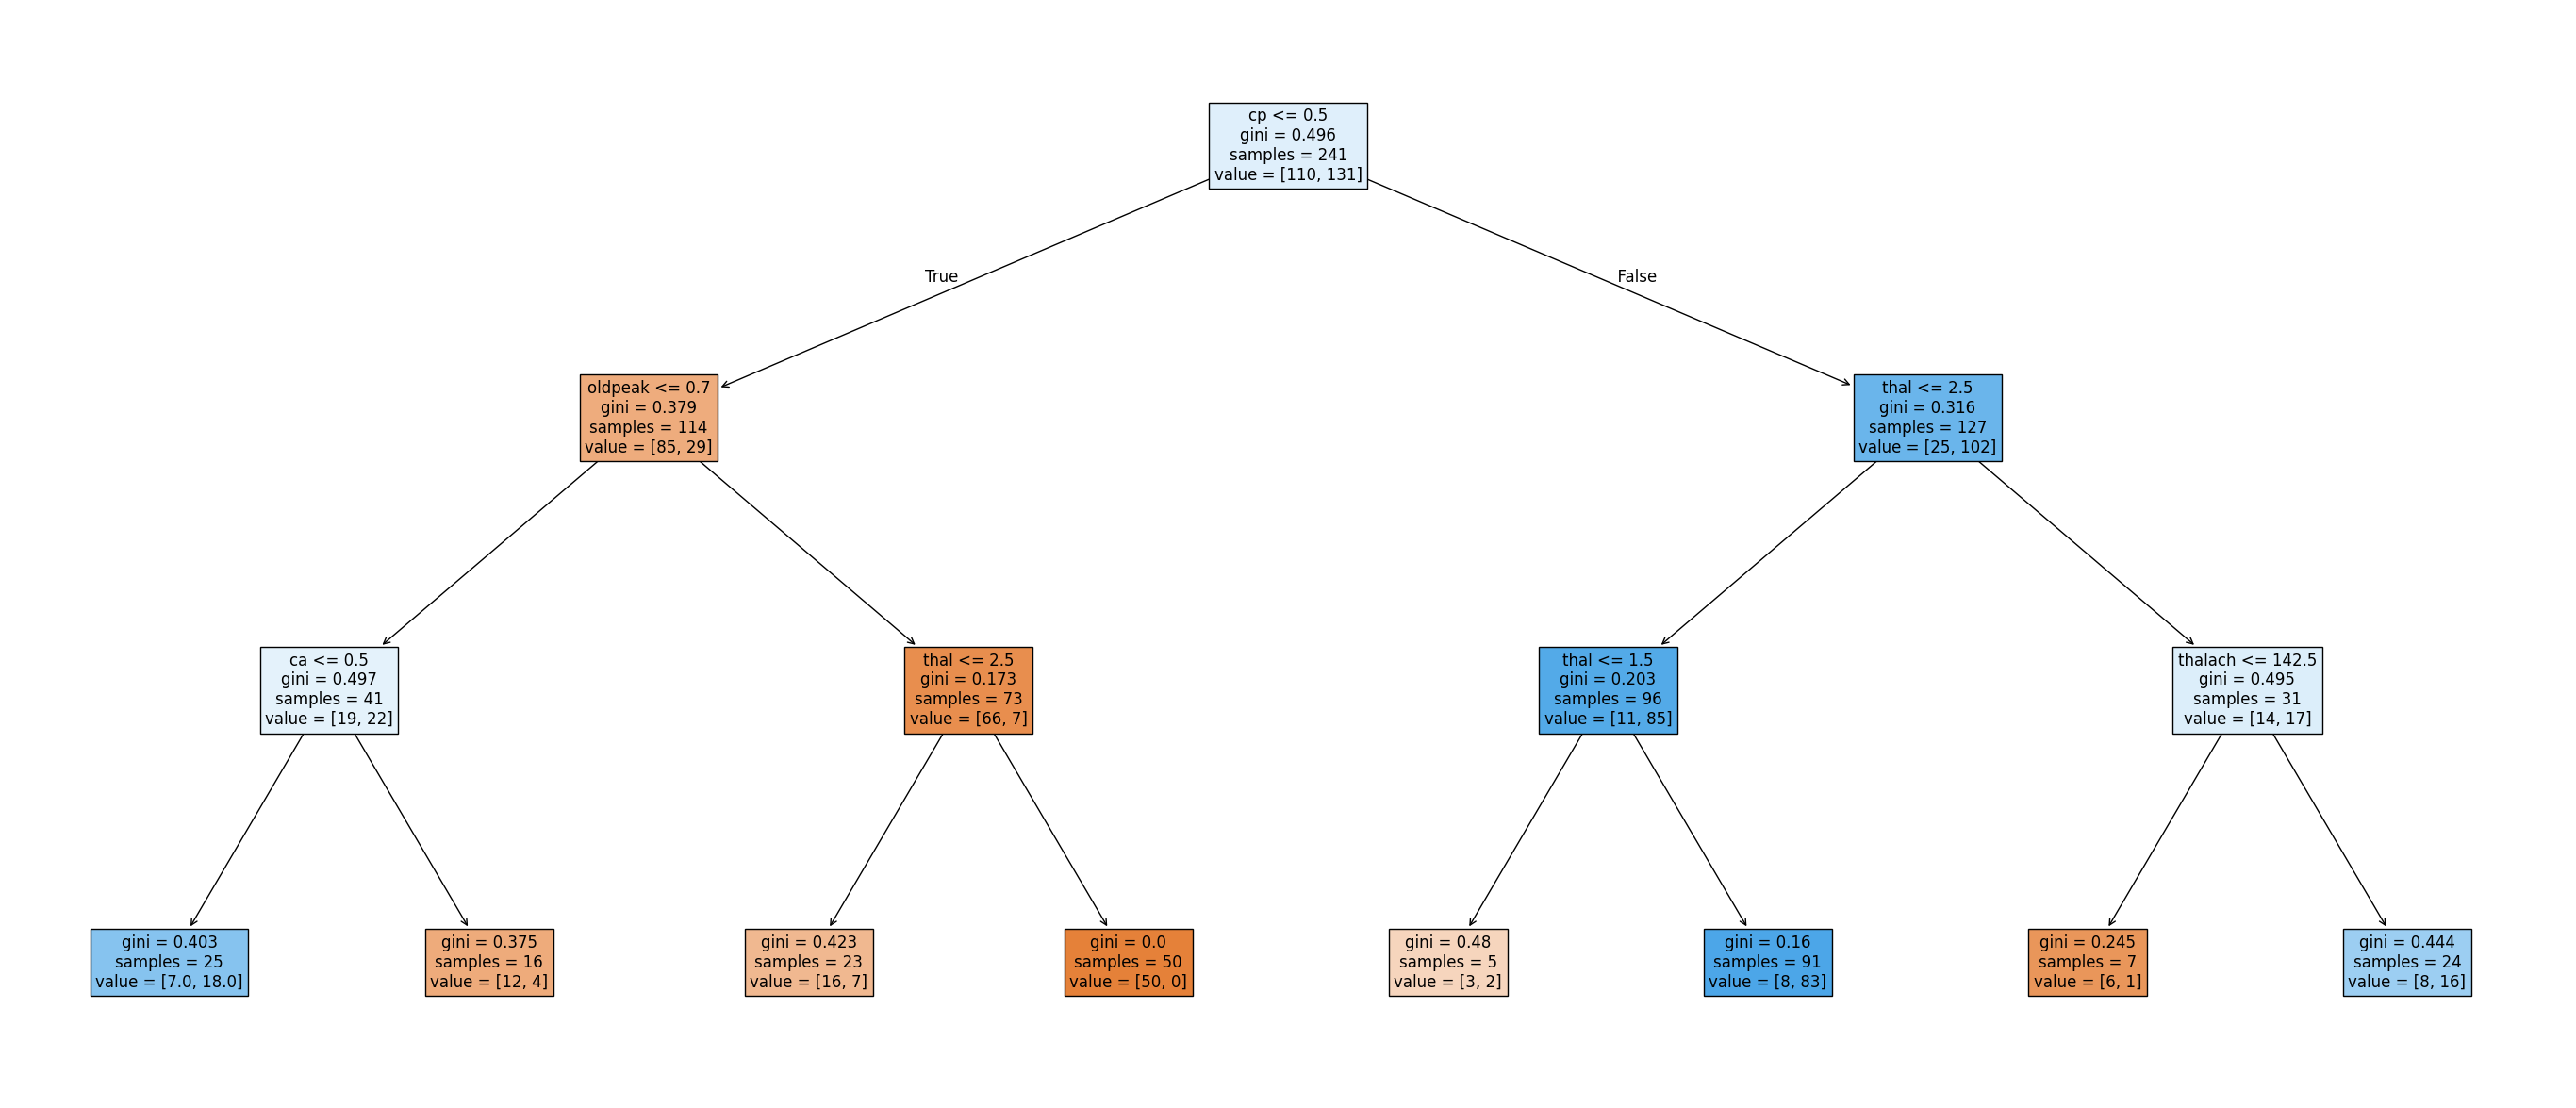

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(35, 15))
plot_tree(model, feature_names=list(X.columns), filled=True, fontsize=12)
plt.show()

In [25]:
print(export_text(model, feature_names=list(X.columns)))

|--- cp <= 0.50
|   |--- oldpeak <= 0.70
|   |   |--- ca <= 0.50
|   |   |   |--- class: 1
|   |   |--- ca >  0.50
|   |   |   |--- class: 0
|   |--- oldpeak >  0.70
|   |   |--- thal <= 2.50
|   |   |   |--- class: 0
|   |   |--- thal >  2.50
|   |   |   |--- class: 0
|--- cp >  0.50
|   |--- thal <= 2.50
|   |   |--- thal <= 1.50
|   |   |   |--- class: 0
|   |   |--- thal >  1.50
|   |   |   |--- class: 1
|   |--- thal >  2.50
|   |   |--- thalach <= 142.50
|   |   |   |--- class: 0
|   |   |--- thalach >  142.50
|   |   |   |--- class: 1



In [29]:
from sklearn.model_selection import GridSearchCV
from time import time
start = time()
grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3,4,5,6,None],
    'min_samples_leaf': [1,5,10,20],
    'min_samples_split': [2,10,20]
}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), grid, cv=5, n_jobs=-1)
gs.fit(X_tr, y_tr)
end = time()
print(gs.best_params_)
print(gs.best_score_)
print(gs.best_estimator_.score(X_te, y_te))

print(f"Vaqt: {end-start}")

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
0.7972789115646258
0.7868852459016393
Vaqt: 4.511025428771973
